In [130]:
!pip install nltk emoji contractions -q

In [131]:
import os
import pandas as pd
import numpy as np
import re
import json
import string
import emoji
import contractions
import matplotlib.pyplot as plt

from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# nltk resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [132]:
df = pd.read_csv('tweets.csv')

Verify file format

In [133]:
file_extension = os.path.splitext('tweets.csv')[1]

print('File Format:', file_extension)

File Format: .csv


Data Inspection

In [134]:
df.shape

(11370, 5)

In [135]:
df.columns

Index(['id', 'keyword', 'location', 'text', 'target'], dtype='object')

In [136]:
df.head()

,id,keyword,location,text,target
0,0,ablaze,NaN,"Communal violence in Bhainsa, Telangana. ""Ston...",1
1,1,ablaze,NaN,Telangana: Section 144 has been imposed in Bha...,1
2,2,ablaze,New York City,Arsonist sets cars ablaze at dealership https:...,1
3,3,ablaze,"Morgantown, WV",Arsonist sets cars ablaze at dealership https:...,1
4,4,ablaze,NaN,"""Lord Jesus, your love brings freedom and pard...",0


In [137]:
df.dtypes

,0
id,int64
keyword,object
location,object
text,object
target,int64


In [138]:
df.isnull().sum()

,0
id,0
keyword,0
location,3418
text,0
target,0


data cleaning

In [139]:
before_duplicates = df.shape[0]

df = df.drop_duplicates(subset=['text'])

after_duplicates = df.shape[0]
print('Duplicates Removed:', before_duplicates - after_duplicates)


Duplicates Removed: 147


Handle missing values

In [140]:
before_missing = df.shape[0]
df = df.dropna(subset=['text'])

after_missing = df.shape[0]

print('Rows removed due to missing text:', before_missing - after_missing)



Rows removed due to missing text: 0


In [141]:
# Fill missing values

df['keyword'] = df['keyword'].fillna('unknown')
df['location'] = df['location'].fillna('unknown')

Remove irrelevant columns

In [142]:
if 'id' in df.columns:
    df = df.drop(columns=['id'])

df.columns

Index(['keyword', 'location', 'text', 'target'], dtype='object')

Text Preprocessing

In [143]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()


In [144]:
def clean_text(text):

    text = text.lower()

    # Expand contractions
    text = contractions.fix(text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Remove emojis
    text = emoji.replace_emoji(text, replace='')

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # Lemmatization
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # Join cleaned tokens
    cleaned_text = ' '.join(tokens)

    return cleaned_text

In [145]:
df['cleaned_text'] = df['text'].apply(clean_text)

Save intermediate sample output before and after cleaning.

In [146]:
sample_before = df[['text']].head(5)

print('Before Cleaning:')
sample_before

Before Cleaning:


,text
0,"Communal violence in Bhainsa, Telangana. ""Ston..."
1,Telangana: Section 144 has been imposed in Bha...
2,Arsonist sets cars ablaze at dealership https:...
3,Arsonist sets cars ablaze at dealership https:...
4,"""Lord Jesus, your love brings freedom and pard..."


In [147]:
sample_after = df[['cleaned_text']].head(5)

print('after Cleaning:')
sample_after

after Cleaning:


,cleaned_text
0,communal violence bhainsa telangana stone pelt...
1,telangana section imposed bhainsa january clas...
2,arsonist set car ablaze dealership
3,arsonist set car ablaze dealership
4,lord jesus love brings freedom pardon fill hol...


 Final Validation

In [148]:
label_counts = df['target'].value_counts()
label_counts

,count
target,
0,9153
1,2070


 bar chart

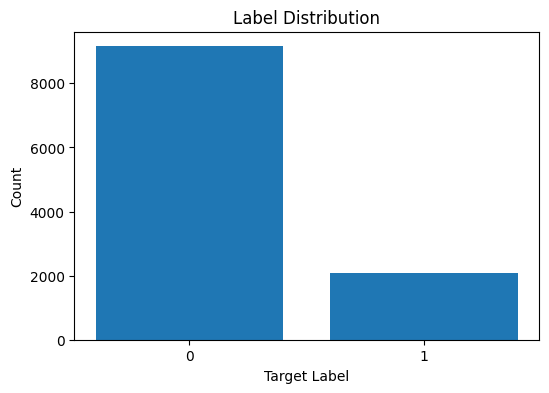

In [149]:
plt.figure(figsize=(6,4))
plt.bar(label_counts.index.astype(str), label_counts.values)

plt.xlabel('Target Label')
plt.ylabel('Count')
plt.title('Label Distribution')

plt.show()

token length distribution and remove outliers

In [150]:
# Count token length

df['token_length'] = df['cleaned_text'].apply(lambda x: len(x.split()))

print(df['token_length'].describe())

count    11223.000000
mean         9.414060
std          3.251131
min          0.000000
25%          7.000000
50%         10.000000
75%         12.000000
max         22.000000
Name: token_length, dtype: float64


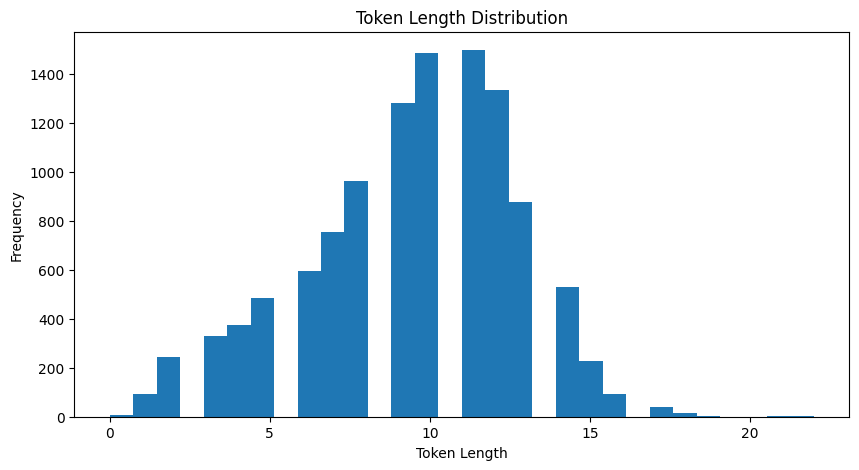

In [151]:
plt.figure(figsize=(10,5))
plt.hist(df['token_length'], bins=30)

plt.xlabel('Token Length')
plt.ylabel('Frequency')
plt.title('Token Length Distribution')

plt.show()

In [152]:
# remove outliers
Q1 = df['token_length'].quantile(0.25)
Q3 = df['token_length'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print('Lower Bound:', lower_bound)
print('Upper Bound:', upper_bound)

Lower Bound: -0.5
Upper Bound: 19.5


In [153]:
before_outlier = df.shape[0]

# Keep normal token lengths

df = df[
    (df['token_length'] >= lower_bound) &
    (df['token_length'] <= upper_bound)
]

after_outlier = df.shape[0]

print('Rows Removed:', before_outlier - after_outlier)
print('Remaining Rows:', after_outlier)

Rows Removed: 2
Remaining Rows: 11221


In [154]:
df.head()

,keyword,location,text,target,cleaned_text,token_length
0,ablaze,unknown,"Communal violence in Bhainsa, Telangana. ""Ston...",1,communal violence bhainsa telangana stone pelt...,12
1,ablaze,unknown,Telangana: Section 144 has been imposed in Bha...,1,telangana section imposed bhainsa january clas...,11
2,ablaze,New York City,Arsonist sets cars ablaze at dealership https:...,1,arsonist set car ablaze dealership,5
3,ablaze,"Morgantown, WV",Arsonist sets cars ablaze at dealership https:...,1,arsonist set car ablaze dealership,5
4,ablaze,unknown,"""Lord Jesus, your love brings freedom and pard...",0,lord jesus love brings freedom pardon fill hol...,13


In [155]:
df.to_csv('cleaned_data.csv', index=False)

In [156]:
with open('cleaned_data.jsonl', 'w') as f:
    for _, row in df.iterrows():
        json_record = row.to_dict()
        f.write(json.dumps(json_record) + '\n')
